In [1]:
import numpy as np
import pandas as pd
from sqlalchemy import create_engine
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings("ignore")

In [2]:
from dotenv import load_dotenv
from pydantic_settings import BaseSettings

load_dotenv()


class Secrets(BaseSettings):
    db_user: str
    db_password: str
    db_host: str
    db_port: str
    db_name: str
    db_table_raw_meat: str

    class Config:
        env_file = ".env"
        env_file_encoding = "utf-8"


secrets = Secrets()

In [3]:
url = f'mysql+pymysql://{secrets.db_user}:{secrets.db_password}@{secrets.db_host}:{secrets.db_port}/{secrets.db_name}'

engine = create_engine(url)
with engine.connect() as conn:
    df_db = pd.read_sql(
        f'''
        SELECT *
        FROM {secrets.db_table_raw_meat}
        WHERE date >= '2020-01-01'
        -- AND product in ('Кура', 'Цыпленок', 'Индейка', 'Гусь', 'Утка', 'Перепел')
        AND product in ('Говядина', 'Телятина', 'Буйволятина')
        ''',
        conn,
        index_col='id'
    )

In [4]:
# добавление макро показателей
macro_df = pd.read_csv('./macroeconomic_indicators.csv')
macro_df.rename(columns={'ds': 'date'}, inplace=True)

cols = ['ВВП','Индекс пром.производства','Цены производителей пром.товаров','Производство пищевых продуктов','Инфляция','Индекс реальной зарплаты']
for col in cols:
    macro_df[col] = macro_df[col].apply(lambda x: float(x[:-1].replace(',', '.')))

macro_df['date'] = pd.to_datetime(macro_df['date'], yearfirst=False, dayfirst=True)

date_range_df = pd.DataFrame(pd.date_range(start='01-01-2018', end='12-01-2025', freq='1d'), columns=['date'])
macro_df = pd.merge(date_range_df, macro_df, on='date', how='left').ffill()
df_db = pd.merge(df_db, macro_df, on='date', how='left')
df_db.head(2)

,category,region,product,description,temperature_state,country,packaging,availability,batch,delivery_terms,...,updated_at,week_number,file_name,hash_value,ВВП,Индекс пром.производства,Цены производителей пром.товаров,Производство пищевых продуктов,Инфляция,Индекс реальной зарплаты
0,Мясо и мясопродукты,None,Говядина,аорта,зам,Россия,None,склад,"от кор. до 1,5 тонн",самовывоз,...,2024-12-25 04:48:17,44,PFO_Meat__31.10.2024.xls,3a58bf51e39451f203f6503e9a2f2c105257e02604926d...,3.2,6.6,8.5,7.3,8.5,5.1
1,Мясо и мясопродукты,None,Говядина,печень 1 сорт,зам,Парагвай,коробки,склад,"от кор. до 1,5 тонн",самовывоз,...,2024-12-25 04:48:17,44,PFO_Meat__31.10.2024.xls,9b54e050c56e3a2ea2cc260640338710bf8f31b0f0a93b...,3.2,6.6,8.5,7.3,8.5,5.1


In [5]:
# добавление курса рубля к доллару
df_rub = pd.read_csv('./rub_dollar_course.csv', encoding='windows-1251')
df_rub['data'] = pd.to_datetime(df_rub['data'])
df_rub = df_rub.drop(['nominal', 'cdx'], axis=1)
df_rub.rename(columns={'data':'date'}, inplace=True)
df_rub = pd.merge(date_range_df, df_rub, on='date', how='left').ffill()
df_db = pd.merge(df_db, df_rub, on='date', how='left')
df_db['curs'].bfill(inplace=True)
df_db['curs'] = df_db['curs'].apply(lambda x:float(x.replace(',', '.')))
df_db.head(2)

,category,region,product,description,temperature_state,country,packaging,availability,batch,delivery_terms,...,week_number,file_name,hash_value,ВВП,Индекс пром.производства,Цены производителей пром.товаров,Производство пищевых продуктов,Инфляция,Индекс реальной зарплаты,curs
0,Мясо и мясопродукты,None,Говядина,аорта,зам,Россия,None,склад,"от кор. до 1,5 тонн",самовывоз,...,44,PFO_Meat__31.10.2024.xls,3a58bf51e39451f203f6503e9a2f2c105257e02604926d...,3.2,6.6,8.5,7.3,8.5,5.1,97.053
1,Мясо и мясопродукты,None,Говядина,печень 1 сорт,зам,Парагвай,коробки,склад,"от кор. до 1,5 тонн",самовывоз,...,44,PFO_Meat__31.10.2024.xls,9b54e050c56e3a2ea2cc260640338710bf8f31b0f0a93b...,3.2,6.6,8.5,7.3,8.5,5.1,97.053


In [6]:
df_db = df_db.drop(df_db[df_db['price'] == 0].index, axis=0)

In [7]:
def transform_data(df, category_treshold=5000, drop_outlier=False, drop_traider=False, add_macro_economic=False, add_extra_features=False):
    df = df.copy()
    # удаляем product_type не из говядины
    beef_product_types = ['азу', 'антрекот', 'аорта', 'балык', 'бедро', 'Бескостная', 'бефстроганов', 'бифштекс', 'Блочная', 'вымя', 'вырезка', 'глазной мускул', 'головы', 'голяшка', 'грудинка', 'грудной отруб', 'губы', 'гуляш', 'диафрагма', 'длиннейшая мышца', 'железа', 'желудки', 'жилка', 'жир', 'жир (сырец)', 'задние части', 'илей', 'калтык', 'карбонад', 'кишка', 'книжка', 'копыта', 'кострец', 'кость', 'легкое', 'лопатка', 'лопаточно-плечевая часть', 'лопаточная часть', 'лытка', 'медальон', 'мозги', 'мука мясокостная', 'мышца', 'мякоть', 'мясо', 'набор для гуляша', 'набор для супа', 'набор для тушения', 'набор для холодца', 'ноги', 'нос', 'обрезь', 'обрезь головная',
                          'огузок', 'Односортная', 'оковалок', 'окорок', 'отруб реберный', 'отруб шейный', 'пашина', 'пенис', 'передние части', 'передние четверти', 'печень', 'подбедерок', 'поджарка', 'подлопаточная часть', 'полутуши', 'почки', 'путовый сустав', 'рагу', 'ребро', 'рубец', 'рулька', 'селезенка', 'семенники', 'сердце', 'соединительная ткань', 'спинно-поясничный отруб', 'стейк', 'Субпродукты', 'суставы', 'сухожилия', 'сычуг', 'тазобедренный отруб', 'тонкий край', 'трахея', 'тримминг', 'туши', 'уши', 'фарш', 'филе', 'филей', 'хвосты', 'хрящи', 'черева', 'четверти', 'шейная часть', 'шейно-лопаточный отруб', 'шейный отруб', 'шея', 'шкура', 'шпик', 'шпик боковой', 'щека', 'язык']
    df = df[df['product_type'].isin(beef_product_types)]

    # Оставляем категории с большим количеством наблюдений
    group = df.groupby('product_type').count().sort_values('category', ascending=False)
    categories = group[group['category'] > category_treshold].index.to_list()
    df = df[df['product_type'].isin(categories)]

    # удаляем аномального трейдера
    if drop_traider:
        df = df.drop(df[df['company'] == 'ИП Егоров А.К.'].index, axis=0)
        df.drop('company', axis=1, inplace=True)

    # удалем 5% данных по каждой категории в каждом продукте
    if drop_outlier:
        dfs = []
        for product in df['product'].unique().tolist():
            for priduct_type in df['product_type'].unique().tolist():
                df_ = df[(df['product'] == product) & (df['product_type'] == priduct_type)]
                lq, rq = df_['price'].quantile(0.025), df_['price'].quantile(0.975)
                df_ = df_[(df_['price'] > lq) & (df_['price'] < rq)]
                dfs.append(df_)

        df = pd.concat(dfs, axis=0)

    # оставляем необходимые признаки
    cols = ['product', 'country', 'price', 'activity_type', 'date', 'product_type', 'sort', 'certification', 'federal_okrug',  'week_number']
    if add_macro_economic:
        cols.extend(['curs', 'ВВП', 'Индекс пром.производства', 'Цены производителей пром.товаров', 'Производство пищевых продуктов', 'Инфляция', 'Индекс реальной зарплаты'])
    df = df[cols]

    # Заполняем пропуски
    df.fillna({
        'activity_type': df['activity_type'].mode()[0],
        'country': 'unknown',
        'sort': 'unknown',
        'certification': 'unknown',
    }, inplace=True)

    # Сортируем по дате
    df.sort_values(by=['date'], axis=0, ascending=True, inplace=True)
    df.reset_index(inplace=True, drop=True)

    # Добавление дополнительных признаков
    if add_extra_features:
        # Добавление месяца и года
        df['month'] = df['date'].dt.month
        df['year'] = df['date'].dt.year

        # Вспомогательные признаки номера месяца и недели с учетом года
        df['weeknr'] = df['week_number'] + (df['year'] - df['year'].min())*52
        df['monthnr'] = df['month'] + (df['year'] - df['year'].min())*12

        def std(x): return np.std(x)

        # Среднее и стандартное отклонение цены по уникальным комбинациям product и product_type за последнюю неделю и за последних 2, не включая текущую
        group_data = df.groupby(['product', 'product_type', 'weeknr'], group_keys=False)['price'].agg(['mean', std]).reset_index()
        group_data['mean_price_w1'] = group_data.groupby(['product', 'product_type'])['mean'].shift(1)
        group_data['mean_price_w2'] = group_data.groupby(['product', 'product_type'])['mean'].shift(2)
        group_data['std_price_w1'] = group_data.groupby(['product', 'product_type'])['std'].shift(1)
        group_data['std_price_w2'] = group_data.groupby(['product', 'product_type'])['std'].shift(2)
        group_data.drop(['mean', 'std'], axis=1, inplace=True)
        df = df.join(group_data.set_index(['product', 'product_type', 'weeknr']), on=['product', 'product_type', 'weeknr'], how='left')

        # Среднее и стандартное отклонение цены по уникальным комбинациям product и product_type за последний месяц и 3, не включая текущий
        group_data = df.groupby(['product', 'product_type', 'monthnr'], group_keys=False)['price'].agg(['mean', std]).reset_index()
        group_data['mean_price_m1'] = group_data.groupby(['product', 'product_type'])['mean'].shift(1)
        group_data['mean_price_m3'] = group_data.groupby(['product', 'product_type'])['mean'].shift(3)
        group_data['std_price_m1'] = group_data.groupby(['product', 'product_type'])['std'].shift(1)
        group_data['std_price_m3'] = group_data.groupby(['product', 'product_type'])['std'].shift(3)
        group_data.drop(['mean', 'std'], axis=1, inplace=True)
        df = df.join(group_data.set_index(['product', 'product_type', 'monthnr']), on=['product', 'product_type', 'monthnr'], how='left')

        cols = ['mean_price_w1', 'std_price_w1', 'mean_price_m1', 'std_price_m1', 'mean_price_w2', 'std_price_w2', 'mean_price_m3', 'std_price_m3']
        df[cols] = df[cols].bfill()

    # Обработка категориальных признаков
    for col in ['product', 'sort', 'certification', 'federal_okrug']:
        one_hot = pd.get_dummies(df[col], prefix=f'{col}_', drop_first=True)
        df = df.drop(col, axis=1)
        df = df.join(one_hot)

    df[['country', 'activity_type', 'product_type']] = df[['country', 'activity_type', 'product_type']].apply(LabelEncoder().fit_transform)

    # удаление лишних признаков
    df.drop(['date'], axis=1, inplace=True)

    X = df.drop('price', axis=1)
    y = df['price']

    # Приведение к одному порядку
    scaler = StandardScaler()
    cols = X.select_dtypes(include='number').columns.to_list()
    X[cols] = scaler.fit_transform(X[cols])

    return X, y

In [8]:
X, y = transform_data(df_db)
X.head(2)

,country,activity_type,product_type,week_number,product__Говядина,product__Телятина,sort__1 сорт,sort__2 сорт,sort__3 сорт,sort__4 сорт,...,certification__гост,certification__ту,certification__халяль,federal_okrug__ПФО,federal_okrug__СЗФО,federal_okrug__СФО,federal_okrug__Санкт-Петербург,federal_okrug__УФО,federal_okrug__ЦФО,federal_okrug__ЮФО
0,-0.253524,0.486595,0.050272,-1.632968,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,0.852978,-1.252957,-0.861821,-1.632968,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


# Обучение модели

In [9]:
def train(X, y):
    time_cv = TimeSeriesSplit(10, max_train_size=int(len(X) / 5))

    rmse, mae, mape = [], [], []
    for train_index, test_index in time_cv.split(X):
        x_train, y_train, x_test, y_test = X.iloc[train_index], y.iloc[train_index], X.iloc[test_index], y.iloc[test_index]

        model = CatBoostRegressor(
            task_type="GPU",
            devices='0',
            verbose=False
        )
        model.fit(
            x_train,
            y_train,
            use_best_model=True,
            eval_set=(x_test, y_test),
            early_stopping_rounds=100
        )
        preds = model.predict(x_test)

        rmse.append(root_mean_squared_error(y_test, preds))
        mae.append(mean_absolute_error(y_test, preds))
        mape.append(mean_absolute_percentage_error(y_test, preds))

    return rmse, mae, mape

In [10]:
X, y = transform_data(df_db)
rmse, mae, mape = train(X, y)
print(f'rmse: {np.mean(rmse)}, mae: {np.mean(mae)}, mape: {round(np.mean(mape) * 100, 3)} %  / бейзлайн')

X, y = transform_data(df_db, drop_outlier=True)
rmse, mae, mape = train(X, y)
print(f'rmse: {np.mean(rmse)}, mae: {np.mean(mae)}, mape: {round(np.mean(mape) * 100, 3)} %  / удаление выбросов')

X, y = transform_data(df_db, drop_traider=True)
rmse, mae, mape = train(X, y)
print(f'rmse: {np.mean(rmse)}, mae: {np.mean(mae)}, mape: {round(np.mean(mape) * 100, 3)} %  / удаление трейдера')

X, y = transform_data(df_db, drop_outlier=True, drop_traider=True)
rmse, mae, mape = train(X, y)
print(f'rmse: {np.mean(rmse)}, mae: {np.mean(mae)}, mape: {round(np.mean(mape) * 100, 3)} %  / удаление выбросов и трейдера')

X, y = transform_data(df_db, add_macro_economic=True)
rmse, mae, mape = train(X, y)
print(f'rmse: {np.mean(rmse)}, mae: {np.mean(mae)}, mape: {round(np.mean(mape) * 100, 3)} %  / добавление макроэкономических показателей')

X, y = transform_data(df_db, add_extra_features=True)
rmse, mae, mape = train(X, y)
print(f'rmse: {np.mean(rmse)}, mae: {np.mean(mae)}, mape: {round(np.mean(mape) * 100, 3)} %  / добавление агрегированной информации по времени')

X, y = transform_data(df_db, add_extra_features=True, add_macro_economic=True, drop_outlier=True, drop_traider=True)
rmse, mae, mape = train(X, y)
print(f'rmse: {np.mean(rmse)}, mae: {np.mean(mae)}, mape: {round(np.mean(mape) * 100, 3)} %  / все вместе')

rmse: 109.62139381238804, mae: 66.604298670413, mape: 23.295 %  / бейзлайн
rmse: 84.52163840124692, mae: 58.03405485128976, mape: 16.783 %  / удаление выбросов
rmse: 106.28550604839172, mae: 65.59554423342448, mape: 22.897 %  / удаление трейдера
rmse: 82.70719404506028, mae: 57.505636460527434, mape: 16.736 %  / удаление выбросов и трейдера
rmse: 98.00028743044209, mae: 56.06354483888413, mape: 21.973 %  / добавление макроэкономических показателей
rmse: 90.03885638890863, mae: 50.32076156832036, mape: 20.693 %  / добавление агрегированной информации по времени
rmse: 60.98863720433487, mae: 40.32194443837077, mape: 12.738 %  / все вместе


## Анализ занчимости фичей

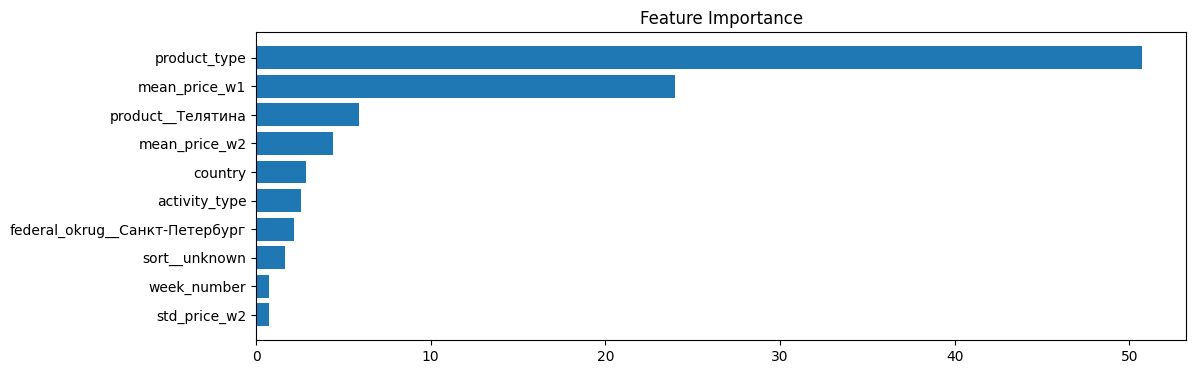

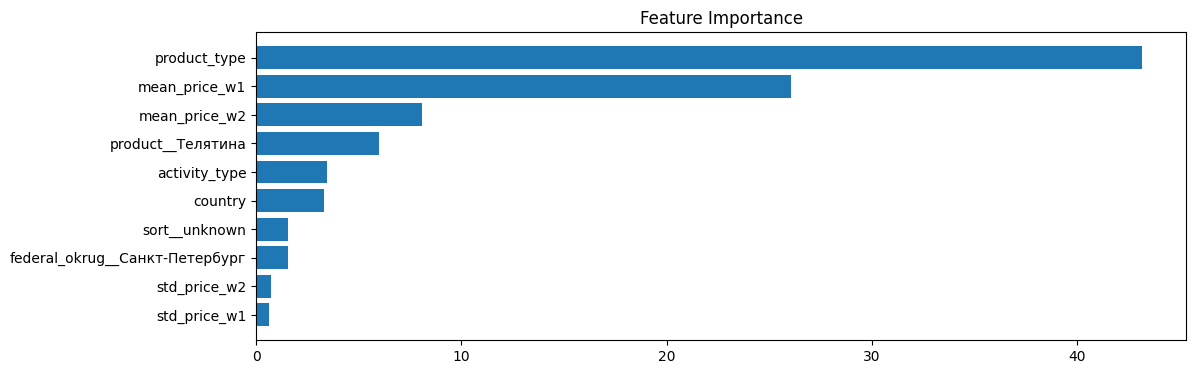

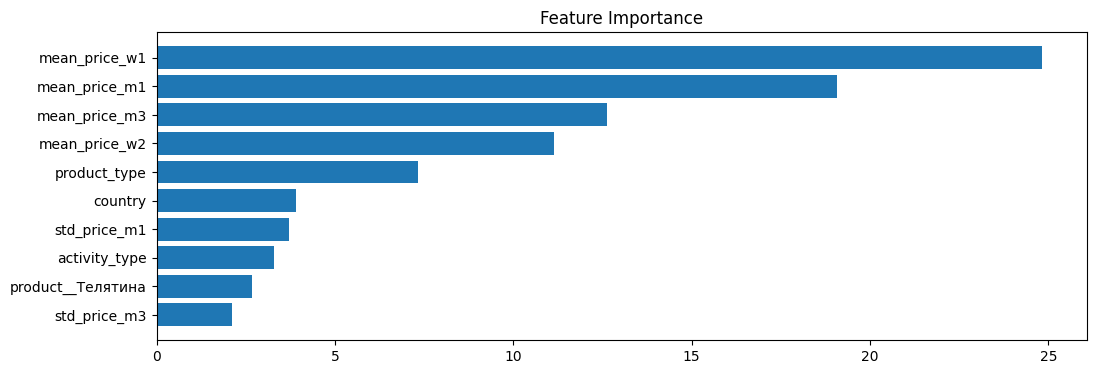

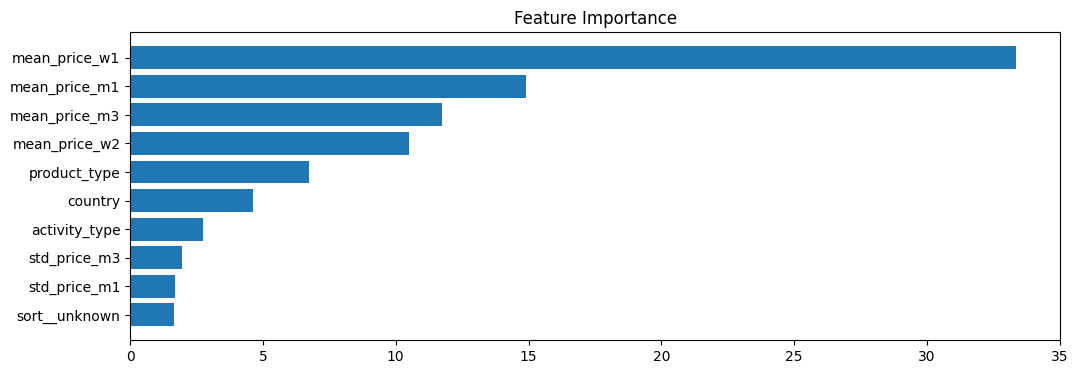

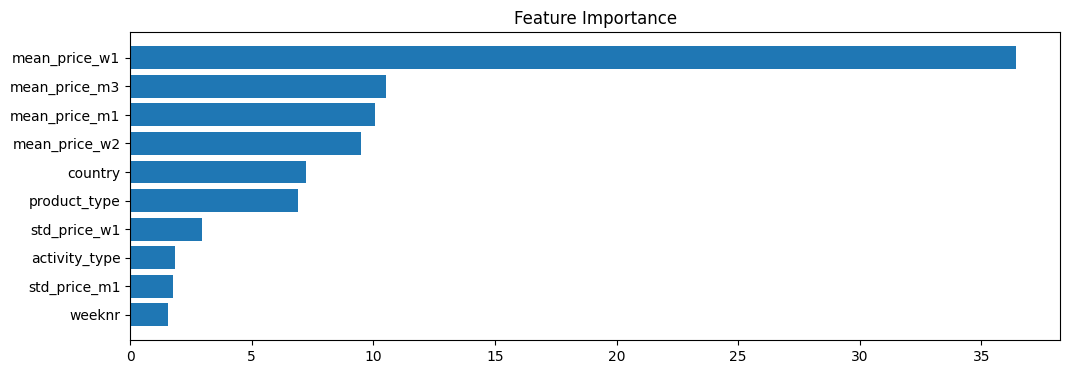

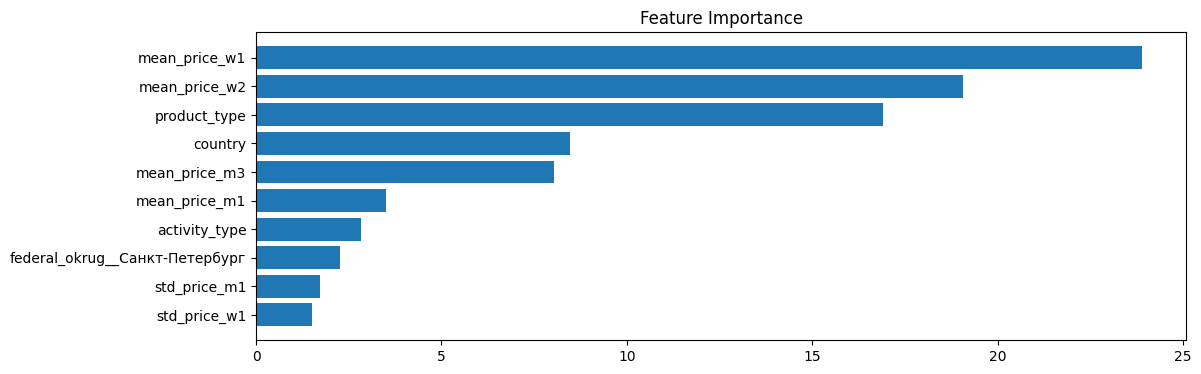

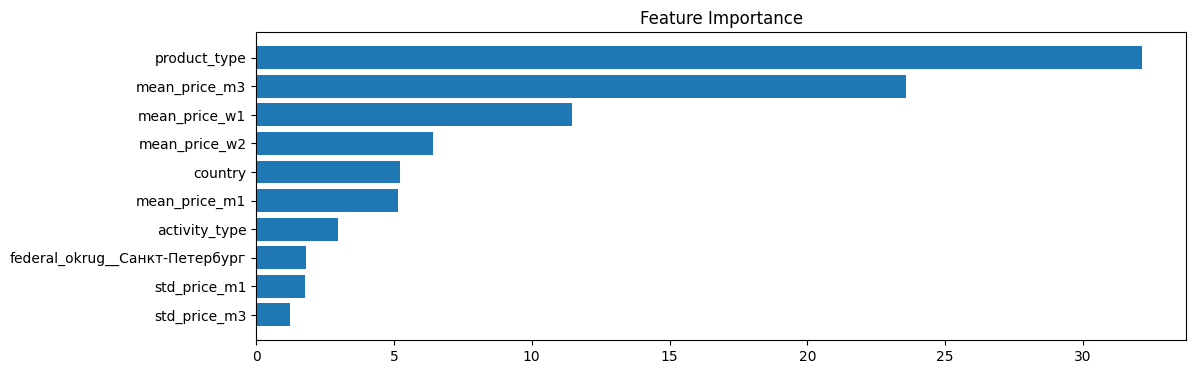

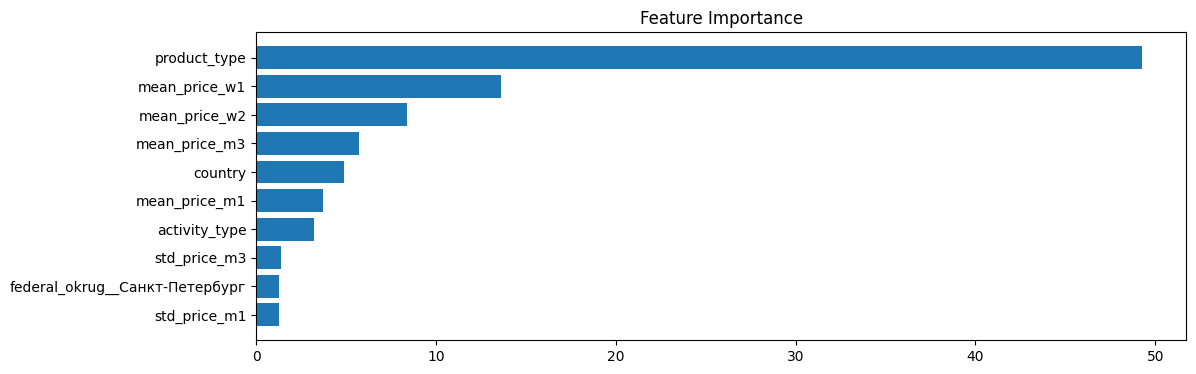

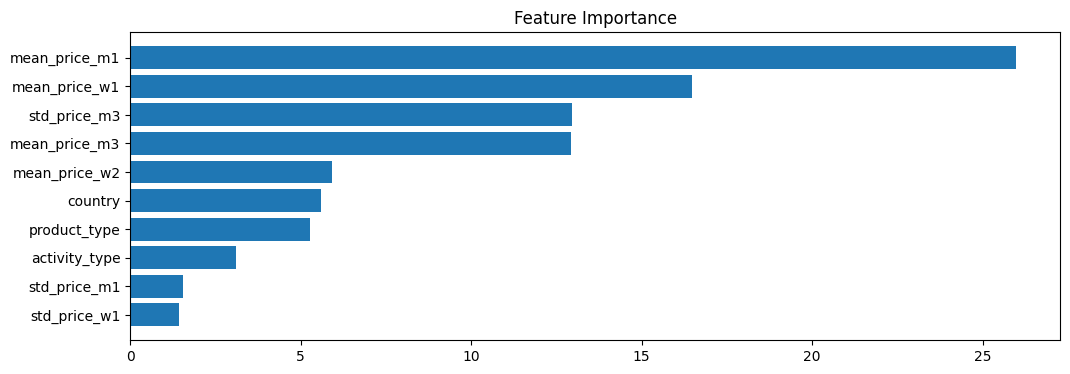

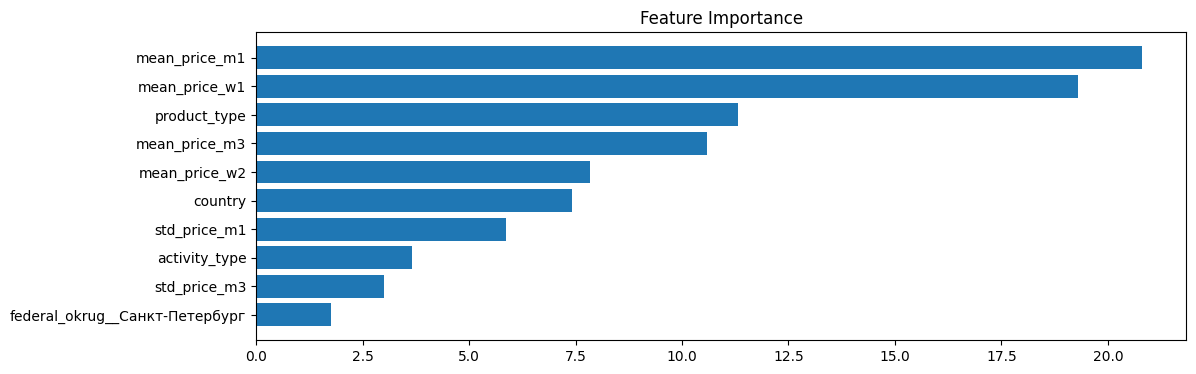

In [11]:
X, y = transform_data(df_db, add_extra_features=True, add_macro_economic=True, drop_outlier=True, drop_traider=True)
time_cv = TimeSeriesSplit(10, max_train_size=int(len(X) / 5))


for train_index, test_index in time_cv.split(X):
    x_train, y_train, x_test, y_test = X.iloc[train_index], y.iloc[train_index], X.iloc[test_index], y.iloc[test_index]

    model = CatBoostRegressor(
        task_type="GPU",
        devices='0',
        verbose=False
    )
    model.fit(
        x_train,
        y_train,
        use_best_model=True,
        eval_set=(x_test, y_test),
        early_stopping_rounds=100
    )

    # plot feature importance
    feature_importance = model.feature_importances_
    sorted_idx = np.argsort(feature_importance)[-10:]
    fig = plt.figure(figsize=(12, 4))
    plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
    plt.yticks(range(len(sorted_idx)), np.array(x_train.columns)[sorted_idx])
    plt.title('Feature Importance')

Метрики по историческим данным вносят наибольший вклад в предсказание. Один из основных минусов работы с данными без группировки по одинаковым временным промежуткам, не понятно на какой горизонт модель делает предсказание